13-Sep-2026 15:51:58 DEBUG utils - Directory ./data already exists. Skipping.
13-Sep-2026 15:51:58 INFO GEOparse - File already exist: using local version.
13-Sep-2026 15:51:58 INFO GEOparse - Parsing ./data\GSE42872_family.soft.gz: 
13-Sep-2026 15:51:58 DEBUG GEOparse - DATABASE: GeoMiame
13-Sep-2026 15:51:58 DEBUG GEOparse - SERIES: GSE42872
13-Sep-2026 15:51:58 DEBUG GEOparse - PLATFORM: GPL6244


⏳ 正在加载 GSE42872 数据...


13-Sep-2026 15:52:02 DEBUG GEOparse - SAMPLE: GSM1052615
13-Sep-2026 15:52:02 DEBUG GEOparse - SAMPLE: GSM1052616
13-Sep-2026 15:52:02 DEBUG GEOparse - SAMPLE: GSM1052617
13-Sep-2026 15:52:02 DEBUG GEOparse - SAMPLE: GSM1052618
13-Sep-2026 15:52:02 DEBUG GEOparse - SAMPLE: GSM1052619
13-Sep-2026 15:52:03 DEBUG GEOparse - SAMPLE: GSM1052620


✅ 加载成功！样本数：6
原始表达矩阵：33297 个探针 × 6 个样本
⏳ 正在转换探针ID为基因名...
✅ 成功匹配 25196 个探针-基因对应关系
基因名示例： ['OR4G2P', 'OR4F4', 'LOC728323', 'OR4F29', 'MT', 'MT', 'MT', 'MT', 'AK026836', 'FAM87B']
✅ 转换后矩阵：21625 个基因 × 6 个样本
⏳ 正在进行差异表达分析...

📈 差异表达结果：
  显著上调基因：611 个
  显著下调基因：512 个
  总计：1123 个
✅ 结果已保存为 diff_expr_results.csv 和 significant_genes.csv


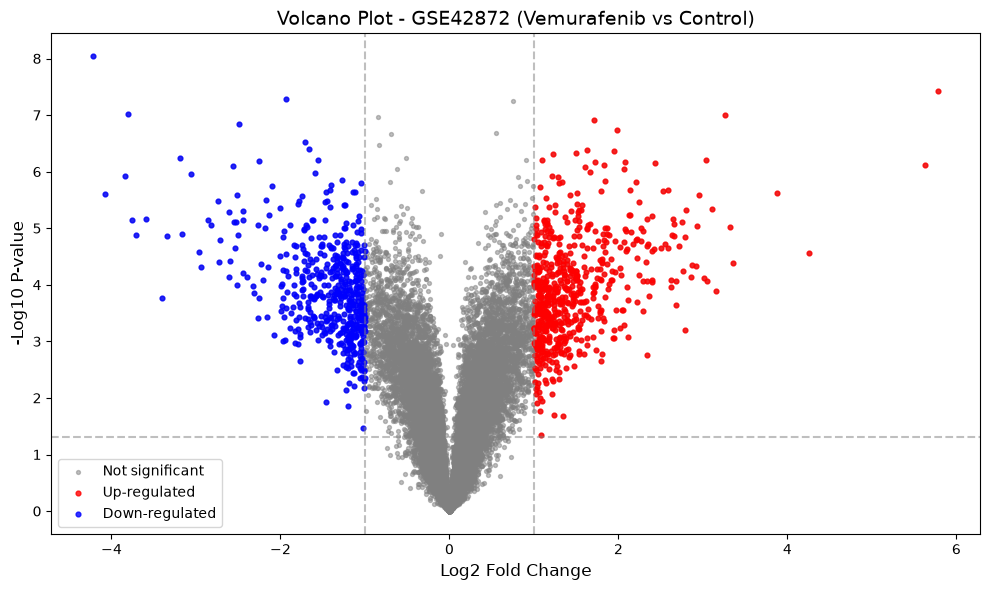

✅ 火山图已保存为 volcano_plot.png


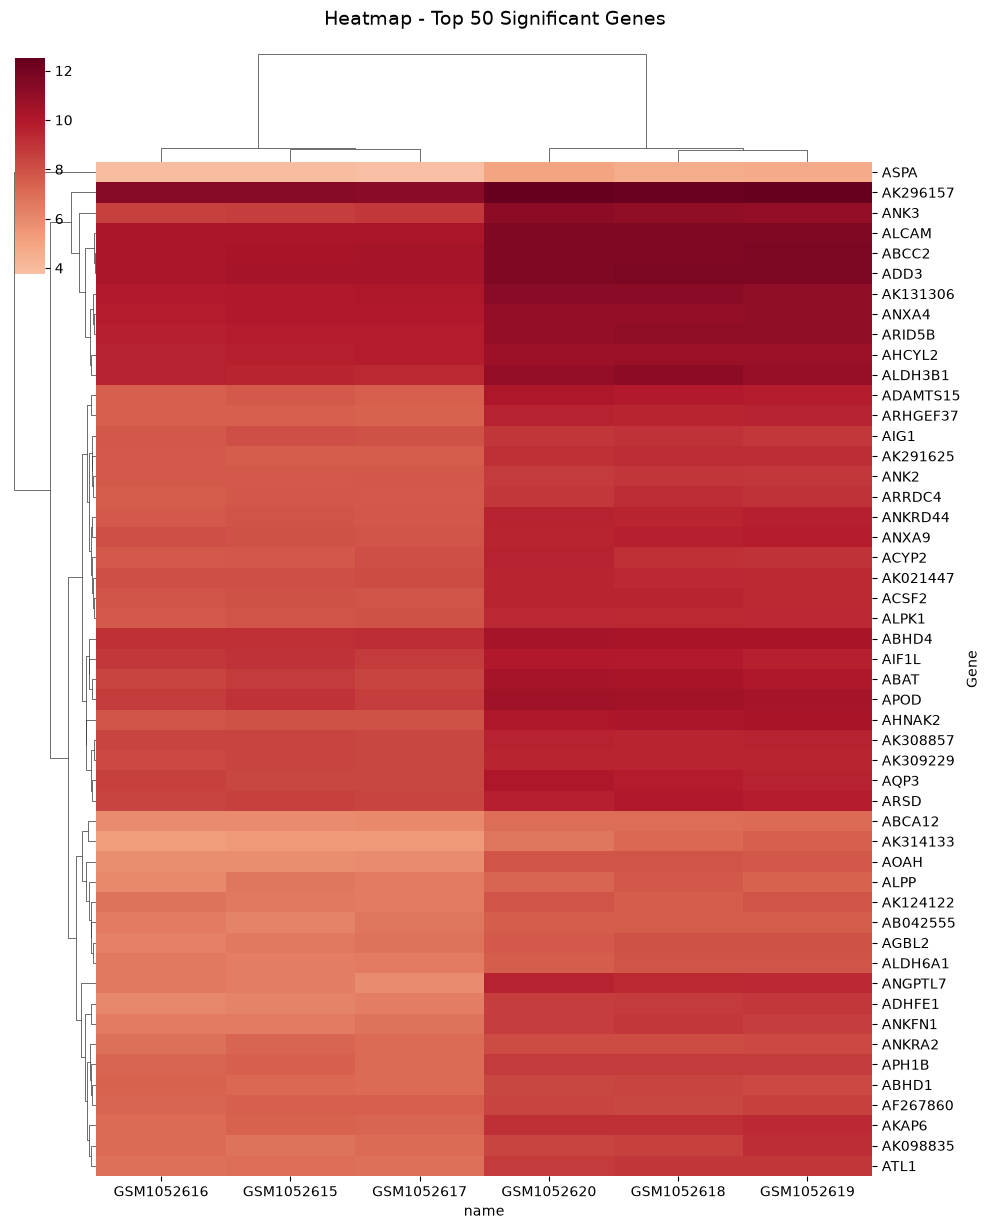

✅ 热图已保存为 heatmap.png

⏳ 正在进行 KEGG 富集分析...
✅ KEGG 富集完成，结果保存在 enrichment_results/ 目录
                         Term       P-value  \
0                  Cell cycle  4.772891e-15   
1             DNA replication  5.143330e-15   
2      Fanconi anemia pathway  1.119381e-06   
3             Mismatch repair  2.145197e-06   
4         Cellular senescence  6.564004e-06   
5    Homologous recombination  1.106540e-05   
6       p53 signaling pathway  7.097125e-04   
7                 Hepatitis B  7.712506e-04   
8           Colorectal cancer  9.807604e-04   
9  Nucleotide excision repair  1.059140e-03   

                                               Genes  
0  PCNA;MCM7;BUB1B;TTK;PKMYT1;CCNB1;ORC6;CDC45;CC...  
1  FEN1;RFC3;PCNA;RFC4;MCM7;RFC2;PRIM1;RPA2;POLD3...  
2  FANCI;BLM;RMI1;FANCA;RPA2;BRCA1;FANCB;BRCA2;BR...  
3     POLD3;POLD4;RFC3;PCNA;RFC4;MSH2;RFC2;EXO1;RPA2  
4  TGFB2;TGFB1;CXCL8;IGFBP3;NFATC2;CACNA1D;PIK3R1...  
5  POLD3;POLD4;BLM;BRIP1;RAD51;EME1;XRCC2;RAD54L;...  
6  CCNB1;RRM2;

In [1]:
# ============================================================
# GEO数据挖掘全流程 - GSE42872 (Vemurafenib vs Control)
# 包括：加载数据、探针注释、差异分析、火山图、热图、富集、结果保存
# ============================================================

import GEOparse
import pandas as pd
import numpy as np
import re
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Entrez
import warnings
warnings.filterwarnings('ignore')

# ---------- 1. 加载数据 ----------
Entrez.email = "2099130700@qq.com"
print("⏳ 正在加载 GSE42872 数据...")
gse = GEOparse.get_GEO(geo="GSE42872", destdir="./data")
print(f"✅ 加载成功！样本数：{len(gse.gsms)}")

# ---------- 2. 提取表达矩阵 ----------
expr_matrix = gse.pivot_samples('VALUE')
print(f"原始表达矩阵：{expr_matrix.shape[0]} 个探针 × {expr_matrix.shape[1]} 个样本")
expr_matrix.index = expr_matrix.index.astype(str)

gpl = gse.gpls[list(gse.gpls.keys())[0]]

# ---------- 3. 探针ID转Gene Symbol（正则提取第一个基因符号） ----------
print("⏳ 正在转换探针ID为基因名...")
gene_pattern = re.compile(r'\b[A-Z][A-Z0-9]{1,9}\b')

probe_to_gene = {}
for _, row in gpl.table.iterrows():
    probe_id = str(row['ID'])
    assignment = str(row['gene_assignment'])
    if assignment and assignment != 'nan':
        match = gene_pattern.search(assignment)
        if match:
            probe_to_gene[probe_id] = match.group(0)

print(f"✅ 成功匹配 {len(probe_to_gene)} 个探针-基因对应关系")
print("基因名示例：", list(probe_to_gene.values())[:10])

# 映射 + 同基因多探针取均值
expr_matrix['Gene'] = expr_matrix.index.map(probe_to_gene)
expr_matrix = expr_matrix.dropna(subset=['Gene']).groupby('Gene').mean()
print(f"✅ 转换后矩阵：{expr_matrix.shape[0]} 个基因 × {expr_matrix.shape[1]} 个样本")

# ---------- 4. 样本分组 ----------
control_samples = ['GSM1052615', 'GSM1052616', 'GSM1052617']  # Control
treat_samples   = ['GSM1052618', 'GSM1052619', 'GSM1052620']  # Vemurafenib

control_expr = expr_matrix[control_samples]
treat_expr   = expr_matrix[treat_samples]

# ---------- 5. 差异表达分析 ----------
print("⏳ 正在进行差异表达分析...")
results = []
for gene in expr_matrix.index:
    c = control_expr.loc[gene].values
    t = treat_expr.loc[gene].values
    log2fc = np.mean(t) - np.mean(c)   # 数据已 log2，差值即 log2FC
    _, p_val = stats.ttest_ind(t, c, nan_policy='omit')
    results.append({'Gene': gene, 'log2FC': log2fc, 'Pvalue': p_val})

results_df = pd.DataFrame(results)
results_df['Padj'] = results_df['Pvalue'] * len(results_df)   # Bonferroni 校正

sig_up   = results_df[(results_df['log2FC'] >  1) & (results_df['Pvalue'] < 0.05)]
sig_down = results_df[(results_df['log2FC'] < -1) & (results_df['Pvalue'] < 0.05)]
sig_all  = pd.concat([sig_up, sig_down])

print(f"\n📈 差异表达结果：")
print(f"  显著上调基因：{len(sig_up)} 个")
print(f"  显著下调基因：{len(sig_down)} 个")
print(f"  总计：{len(sig_all)} 个")

results_df.to_csv('diff_expr_results.csv', index=False)
sig_all.to_csv('significant_genes.csv', index=False)
print("✅ 结果已保存为 diff_expr_results.csv 和 significant_genes.csv")

# ---------- 6. 火山图 ----------
plt.figure(figsize=(10, 6))
plt.scatter(results_df['log2FC'], -np.log10(results_df['Pvalue']),
            alpha=0.5, s=8, color='gray', label='Not significant')
plt.scatter(sig_up['log2FC'], -np.log10(sig_up['Pvalue']),
            alpha=0.8, s=12, color='red', label='Up-regulated')
plt.scatter(sig_down['log2FC'], -np.log10(sig_down['Pvalue']),
            alpha=0.8, s=12, color='blue', label='Down-regulated')
plt.axhline(y=-np.log10(0.05), linestyle='--', color='gray', alpha=0.5)
plt.axvline(x= 1, linestyle='--', color='gray', alpha=0.5)
plt.axvline(x=-1, linestyle='--', color='gray', alpha=0.5)
plt.xlabel('Log2 Fold Change', fontsize=12)
plt.ylabel('-Log10 P-value', fontsize=12)
plt.title('Volcano Plot - GSE42872 (Vemurafenib vs Control)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('volcano_plot.png', dpi=300)
plt.show()
print("✅ 火山图已保存为 volcano_plot.png")

# ---------- 7. 热图 (Top50 差异基因) ----------
top_genes = sig_all.head(50) if len(sig_all) > 50 else sig_all
heatmap_data = expr_matrix.loc[top_genes['Gene']]

g = sns.clustermap(heatmap_data, cmap='RdBu_r', center=0,
                   figsize=(10, 12), dendrogram_ratio=0.1,
                   cbar_pos=(0.02, 0.8, 0.03, 0.18))
g.fig.suptitle('Heatmap - Top 50 Significant Genes', y=1.02, fontsize=14)
g.savefig('heatmap.png', dpi=300)
plt.show()
print("✅ 热图已保存为 heatmap.png")

# ---------- 8. KEGG 富集分析 ----------
try:
    import gseapy as gp
    if len(sig_all) > 10:
        gene_list = sig_all['Gene'].tolist()
        print("\n⏳ 正在进行 KEGG 富集分析...")
        kegg_enr = gp.enrichr(gene_list=gene_list,
                              gene_sets='KEGG_2021_Human',
                              organism='human',
                              outdir='enrichment_results')
        print("✅ KEGG 富集完成，结果保存在 enrichment_results/ 目录")
        print(kegg_enr.results[['Term', 'P-value', 'Genes']].head(10))
    else:
        print("⚠️ 显著基因太少，跳过富集分析")
except Exception as e:
    print(f"⚠️ 富集分析失败（可能是网络问题）：{e}")

print("\n🎉 全部分析完成！相关文件已保存在当前目录。")